In [1]:
#Simulation central limit theorem
#1 sample
import numpy as np
from scipy import stats
rng = np.random.default_rng(42)

one = rng.exponential(scale=20, size=5)
print(one.round(1))        # [48.1 46.7 47.7  5.6  1.7]
print(one.mean())          # 29.97

#Five waits: 48, 47, 48, 6, 2 minutes. Average 30, while the truth is 20. One small sample is a noisy guess.

[48.1 46.7 47.7  5.6  1.7]
29.965563796858653


In [2]:
# 10,000 samples at once (a matrix
samples = rng.exponential(scale=20, size=(10_000, 30))
print(samples.shape)           # (10000, 30)
print(samples[0, :5].round(1)) # [29.1 28.2 62.5  1.6 20.9]

(10000, 30)
[29.1 28.2 62.5  1.6 20.9]


In [4]:
means = samples.mean(axis=1)
print(means.shape)             # (10000,)
print(means[:5].round(2))      # [15.71 19.81 16.98 18.2  22.36]

print(means.mean())                 # 19.968   ← truth is 20 ✔
print(means.std(ddof=1))            # 3.670
print(20 / np.sqrt(30))             # 3.651    ← theory ✔

(10000,)
[15.71 19.81 16.98 18.2  22.36]
19.9675306635036
3.6698765873241905
3.6514837167011076


In [5]:
print(stats.skew(samples.ravel()))  # 2.02   ← raw waiting times: very lopsided
print(stats.skew(means))            # 0.34   ← averages: nearly symmetric

2.01803206362148
0.33981646778608043


In [6]:
#bonus check: does the 68-95-99.7 rule hold?
z = (means - means.mean()) / means.std(ddof=1)
print((np.abs(z) < 1).mean())     # 0.686   (normal: 0.683)
print((np.abs(z) < 2).mean())     # 0.957   (normal: 0.954)
print((np.abs(z) < 3).mean())     # 0.997   (normal: 0.997)

0.6856
0.9574
0.9966


In [7]:
counts, edges = np.histogram(means, bins=12)
for c, lo in zip(counts, edges[:-1]):
    print(f"{lo:6.1f} | " + "#" * int(c / 60))

   9.2 | 
  11.6 | ######
  14.0 | ####################
  16.4 | #######################################
  18.8 | #########################################
  21.2 | ###############################
  23.6 | #################
  26.0 | ######
  28.4 | ##
  30.8 | 
  33.2 | 
  35.6 | 


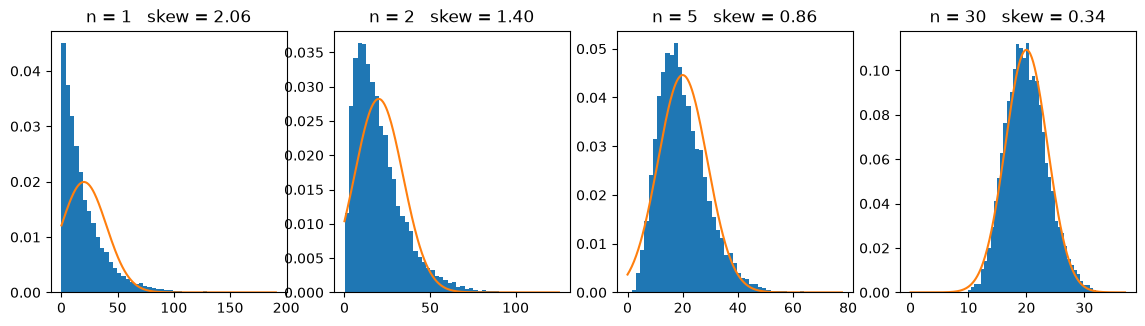

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, n in zip(axes, [1, 2, 5, 30]):
    m = rng.exponential(20, size=(10_000, n)).mean(axis=1)
    ax.hist(m, bins=50, density=True)
    x = np.linspace(0, m.max(), 300)
    ax.plot(x, stats.norm.pdf(x, 20, 20 / np.sqrt(n)))
    ax.set_title(f"n = {n}   skew = {stats.skew(m):.2f}")
plt.show()

In [ ]:
# Broadcasting rules:Broadcasting is how numpy does maths between arrays of different shapes, by automatically "stretching" the smaller one to fit, without copying data.

